# Imports

In [104]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message=".*anndata.*", category=FutureWarning)
plt.rcParams["font.family"] = "Arial"
# - dirs 
from ciim.src.common import plots_dir, datasets_all, aging_clock_train_datasets, aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, save_dir, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.tf_activity.helper import retrieve_sig_stats
from ciim.src.insilico_perturbation.helper import wrapper_in_silico_perturbation
from ciim.src.insilico_perturbation.plots import plot_age_acceleration
from ciim.src.utils.util import get_genesets

reg_type = 'ridge'
version = 'all_data'
data_type = 'bulk'

n_jobs = 5
simulation_iteration = 3
n_donors = 20

cell_types = ['CD4T', 'CD8T'] #['CD4T', 'CD8T',  'NK', 'MONO']
opengenes_terms = get_genesets('opengenes')
gene_score_shift_col = 'gene_score_shift_log2fc'

In [115]:
def multi_tf_run_function(tfs):
    par = {
        'simulation_iteration': simulation_iteration,
        'n_donors': n_donors,
        'data_type': data_type,
        'version': version,
        'reg_type': reg_type,
        'feature_type': 'gene_expression',
        'perturbation_mode': 'overexpression',
        'tfs': tfs,
    }
    raw_rr = wrapper_in_silico_perturbation(par, n_jobs=n_jobs, cell_types=[cell_type], datasets=datasets)
    return raw_rr

def heatplot_perturbation_effect(pivot_df, ax):
    from matplotlib.colors import LinearSegmentedColormap
    custom_cmap = LinearSegmentedColormap.from_list(
        'aging_effect_cmap',
        [palette_trend_2['Decrease in aging'], 'white', palette_trend_2['Increase in aging']]
    )
    cbar_label = 'Gene score shift \n (log2FC)' if 'log2fc' in gene_score_shift_col else 'Gene score shift'
    sns.heatmap(pivot_df, 
                cmap=custom_cmap, 
                center=0, 
                linewidths=0.1, 
                linecolor=None,
                ax=ax,
                cbar_kws={'label': cbar_label, 'shrink': 0.6})
    ax.set_ylabel('')
    ax.set_xlabel('Number of top TFs perturbed')
    ax.set_title('')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
def summarize_pathway_scores(raw_rr, cols=['cell_type', 'dataset', 'n']):
    terms = list(get_genesets().keys())
    df_store = []
    for term in terms:
        if term not in raw_rr.columns:
            continue
        df_sub_store = []
        for i, col in enumerate(['baseline_gene_score', 'perturbed_gene_score' ,'gene_score_shift']):
            df = raw_rr.groupby(cols)[term].mean()[term][col].reset_index()
            if i == 0:
                df_sub_store.append(df)
            else:
                df_sub_store.append(df[[col]])
        df = pd.concat(df_sub_store, axis=1)
        df['pathway'] = term
        df_store.append(df)
    score_shift_summary = pd.concat(df_store).reset_index(drop=True)
    baseline_adj = score_shift_summary['baseline_gene_score'].abs().quantile(.25)
    score_shift_summary['gene_score_shift_n'] = score_shift_summary['gene_score_shift'].abs() / (score_shift_summary['baseline_gene_score'] )

    score_shift_summary['gene_score_shift_log2fc'] = np.log2((score_shift_summary['gene_score_shift'].abs() + baseline_adj) / (score_shift_summary['baseline_gene_score'].abs() + baseline_adj))
    
    return score_shift_summary

# Pathway genes perturbation

In [106]:
from ciim.src.tf_activity.helper import get_consensus_net
cell_type = 'CD8T'
target_pathways = ['MTORC1 SIGNALING']
# P53 PATHWAY -> senolytics
# PI3K AKT MTOR SIGNALING, 'MTORC1 SIGNALING' -> rapamycin
# IL6 JAK STAT3 SIGNALING -> Ruxolitinib
#  'MYC TARGETS V1'
tf_selection_type = 'top_tfs' #  'top_tfs', 'top_enriched_tfs'

pathways = get_genesets()
pathway_genes = [
    gene
    for tp in target_pathways
    for gene in pathways[tp]
]
grn = get_consensus_net(cell_type=cell_type)
grn_pathway = grn[grn['target'].isin(pathway_genes)]

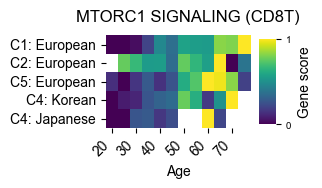

In [107]:
from ciim.src.tf_activity.plots import plot_feature_values_all_datasets, plot_feature_values_per_datasets
for case_term in target_pathways:
    datasets = datasets = [d for d in datasets_all if d != 'data12']

    fig, ax = plt.subplots(1, 1, figsize=(2.2, 1.2))

    plot_feature_values_all_datasets(cell_type, feature=case_term, feature_type='gene_score', type='bulk', datasets=datasets, show_cbar=True, ax=ax,
                                        show_ylabels=True)


    plt.suptitle(f'{case_term} ({cell_type})', y=1.1)
    plt.savefig(f'{plots_dir}/{case_term}_{cell_type}.png', bbox_inches='tight', dpi=300, transparent=True)

In [108]:
if False:
    from ciim.src.utils.util import get_genesets
    terms = []
    for term in pathways.keys():
        if ('mtor' in term.lower()) | ('ampk' in term.lower()):
            print(term, len(pathways[term]))
            terms.append(term)
    pathways = {k: pathways[k] for k in terms}

## Top regulators of the pathway genes: overall regualtors

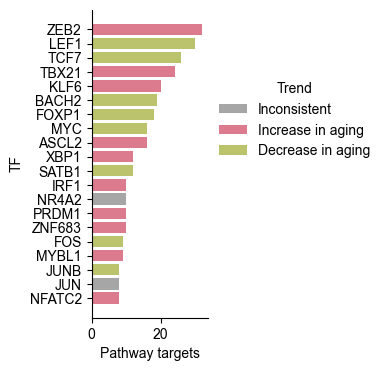

In [109]:
tf_counts = grn_pathway['source'].value_counts().sort_values(ascending=False)
tf_counts_top = tf_counts.head(20).reset_index()  # Limit to top 20 TFs for clarity

stats_aging = retrieve_sig_stats(cell_type=cell_type).drop_duplicates(subset=['cell_type', 'tf', 'trend']).reset_index(drop=True)[['tf', 'trend']]

tf_counts_top = tf_counts_top.merge(stats_aging, left_on='source', right_on='tf', how='left').fillna('Inconsistent')
tf_counts_top['trend'] = pd.Categorical(
    tf_counts_top['trend'],
    categories=palette_trend.keys(),
    ordered=True
)
# Plot

fig, ax = plt.subplots(figsize=(1.5, 4))
tf_counts_top = tf_counts_top.sort_values('count', ascending=True)

sns.barplot(
        data=tf_counts_top,
        y='source',
        x='count',
        hue='trend',
        color=colors_blind[2],
        palette=palette_trend,
        edgecolor='black',
        linewidth=0.01,  
        alpha=.7,
        ci=None,
        ax=ax
    )
ax.margins(y=.05)
# Aesthetics
ax.invert_yaxis()  # Largest count at the top
ax.set_xlabel('Pathway targets')
ax.set_ylabel('TF')
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
ax.legend(loc=[1.05, 0.5], title='Trend',frameon=False, markerscale=1)
plt.savefig(f'{plots_dir}/tf_counts_pathway.png', bbox_inches='tight', dpi=300, transparent=True)
# plt.title(f'{}', fontsize=8)

## To regulators of the given pathway genes: enriched regulators

In [110]:
from scipy.stats import fisher_exact

# All TFs in the GRN
all_tfs = grn['source'].unique()

# Set of all targets and pathway targets
all_targets = set(grn['target'])
pathway_targets = set(pathway_genes) & all_targets  # keep only known targets

results = []

for tf in all_tfs:
    tf_targets = set(grn.loc[grn['source'] == tf, 'target'])

    a = len(tf_targets & pathway_targets)                     # TF → pathway target
    b = len(tf_targets - pathway_targets)                     # TF → non-pathway target
    c = len(pathway_targets - tf_targets)                     # other TFs → pathway target
    d = len((all_targets - pathway_targets) - (tf_targets - pathway_targets))  # other TFs → non-pathway

    # Skip TFs with no target or zero counts to avoid math errors
    if (a + b + c + d) == 0 or (a + b == 0) or (c + d == 0):
        continue

    # Fisher's exact test
    oddsratio, pval = fisher_exact([[a, b], [c, d]], alternative='greater')  # test for over-representation

    results.append({
        'TF': tf,
        'n_pathway_targets': a,
        'n_total_targets': a + b,
        'odds_ratio': oddsratio,
        'pval': pval
    })

# Convert to DataFrame
df_enrich = pd.DataFrame(results)

# Adjust for multiple testing (optional)
from statsmodels.stats.multitest import multipletests
df_enrich['pval_adj'] = multipletests(df_enrich['pval'], method='fdr_bh')[1]

# Sort by significance
df_enrich = df_enrich[df_enrich['pval_adj'] < 0.05]
df_enrich = df_enrich.sort_values('pval')
df_enrich

,TF,n_pathway_targets,n_total_targets,odds_ratio,pval,pval_adj
83,NR4A2,10,81,7.21275,0.00001,0.001753


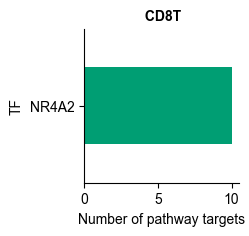

In [111]:
df = df_enrich.sort_values('pval_adj', ascending=True).head(30)
df = df[['TF', 'n_pathway_targets']].set_index('TF')
fig, ax = plt.subplots(figsize=(2, max(2, len(df) * 0.2)))
df.plot(kind='barh', ax=ax, color=colors_blind[2], edgecolor=None)

# Aesthetics
ax.invert_yaxis()  # Largest count at the top
ax.set_xlabel('Number of pathway targets')
ax.set_ylabel('TF')
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
ax.margins(y=0.1)  # Add margins for better visibility
ax.set_title(f' {cell_type}', weight='bold', fontsize=10)
ax.get_legend().remove()  # Remove legend if not needed

## Run perturbation simulation for different selection of TFs

In [112]:
top_tfs_counts = [2, 5, 7, 10, 15, 20, 25, 50]
if tf_selection_type == 'top_tfs': # general regulators
    tfs_list = tf_counts.index.tolist()
elif tf_selection_type == 'top_enriched_tfs':
    tfs_list = df_enrich.sort_values('pval_adj', ascending=True)['TF'].tolist()
else:
    raise ValueError(f'Unknown tf_selection_type: {tf_selection_type}')

In [116]:
from ciim.src.insilico_perturbation.helper import wrapper_in_silico_perturbation
from collections import defaultdict

simulation_iteration = 3
n_donors = 20
n_jobs = 5
datasets = datasets_all

results = defaultdict(list)

raw_rr_store = []
for n in top_tfs_counts:
    # - get top N TFs regulating the pathway
    tfs = tfs_list[:n]

    raw_rr = multi_tf_run_function(tfs) # actual run
    raw_rr['n'] = n
    raw_rr_store.append(raw_rr)

raw_rr = pd.concat(raw_rr_store).reset_index()

Processing: CD8T - SLE_European (overexpression)
Processing: CD8T - data1 (overexpression)
Processing: CD8T - data7_allTPs_jalil (overexpression)
Processing: CD8T - data13_Korean (overexpression)
Processing: CD8T - data12 (overexpression)
Processing: CD8T - data13_Japanese (overexpression)
Processing: CD8T - data1 (overexpression)
Processing: CD8T - data7_allTPs_jalil (overexpression)
Processing: CD8T - data12 (overexpression)
Processing: CD8T - SLE_European (overexpression)
Processing: CD8T - data13_Korean (overexpression)
Processing: CD8T - data13_Japanese (overexpression)
Processing: CD8T - data1 (overexpression)
Processing: CD8T - data7_allTPs_jalil (overexpression)
Processing: CD8T - data12 (overexpression)
Processing: CD8T - SLE_European (overexpression)
Processing: CD8T - data13_Korean (overexpression)
Processing: CD8T - data13_Japanese (overexpression)
Processing: CD8T - data1 (overexpression)
Processing: CD8T - data7_allTPs_jalil (overexpression)
Processing: CD8T - data12 (ove

## Plot age shift and gene score shift per donor

In [117]:
if False: # donor level plot
    from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
    datasets = raw_rr['dataset'].unique()
    n_datasets = len(datasets)
    # for n in raw_rr['n'].unique():
    for n in [10]:
        rr = raw_rr[raw_rr['n'] == n].copy()
        fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
        for i, dataset in enumerate(datasets):
            ax = axes[i] if n_datasets > 1 else axes
            rr_sub = rr[(rr['cell_type'] == cell_type) & (rr['dataset'] == dataset)].copy()
            df = rr_sub['age_shift']
            df['donor_age'] = rr_sub['donor_age']
            plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
            ax.set_title(f"{surrogate_names[dataset]}", pad=10)

        plt.suptitle(f"{cell_type}: {n}", y=1.25, fontsize=12, fontweight='bold')

## Plot the effect of perturbation on aging pathways 

In [118]:
# - summary of pathway gene score shift
score_shift_summary = summarize_pathway_scores(raw_rr)
# - subset to aging tfs
if False: 
    stats_sig = retrieve_sig_stats(feature_type='gene_score').drop_duplicates(subset=['cell_type', 'pathway'])[['pathway', 'cell_type', 'slope']].rename(columns={'slope': 'spearman_slope'})
    # stats_sig = stats_sig[stats_sig['spearman_slope'].abs() > 0.4] # # filter to pathways with significant aging slope -> move this to helper function
    score_shift_summary = score_shift_summary.merge(stats_sig, on=['cell_type', 'pathway'], how='inner')
    print(score_shift_summary.shape)
# print(df_pathway_score_shift_summary['pathway'].value_counts())
if False:
    # - calculate the natural aging slope
    from ciim.src.insilico_perturbation.helper import compute_slopes
    from ciim.src.utils.util.helper import retrieve_feature_data
    slope_store = []
    for dataset in datasets:
        # adata = retrieve_feature_data(cell_type=cell_type, dataset=dataset)
        adata = ad.read_h5ad(f"{save_dir}/gene_expression_smoothed/{dataset}_{cell_type}_bulk.h5ad")
        slope = compute_slopes(adata, feature_type='gene_score')
        slope.index.name = 'pathway'
        slope = slope.reset_index()
        slope['dataset'] = dataset   
        slope_store.append(slope)
    df_slope = pd.concat(slope_store).reset_index(drop=True).rename(columns={'slope': 'aging_slope'})

    # - calculate 10 years slope
    df_slope['aging_slope'] = df_slope['aging_slope'] * 10  # convert to 10 years slope

    score_shift_summary = score_shift_summary.merge(df_slope, on=['dataset', 'pathway'], how='left')

    score_shift_summary['perturbation_effect'] = score_shift_summary['gene_score_shift'] / score_shift_summary['aging_slope']
else:
    score_shift_summary.head()

## Plot age shift and the target pathway's gene score shift for different TF selection

In [119]:
target_pathway = target_pathways[0]
target_pathway

'MTORC1 SIGNALING'

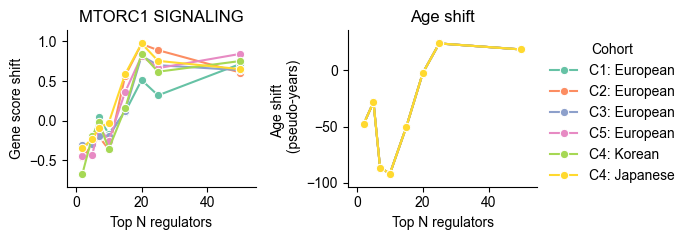

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

age_shift_summary = raw_rr.groupby(['cell_type', 'dataset', 'n'])['age_shift'].mean()['age_shift']['age_shift'].reset_index()
age_shift_summary['dataset'] = pd.Categorical(age_shift_summary['dataset'], categories=datasets_all, ordered=True)
age_shift_summary['dataset'] = age_shift_summary['dataset'].map(surrogate_names)

gene_score_shift_summary = raw_rr.groupby(['cell_type', 'dataset', 'n'])[target_pathway].mean()[target_pathway]['gene_score_shift'].reset_index()

gene_score_shift_summary['dataset'] = pd.Categorical(gene_score_shift_summary['dataset'], categories=datasets_all, ordered=True)
gene_score_shift_summary['dataset'] = gene_score_shift_summary['dataset'].map(surrogate_names)


fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))

ax = axes[0]

sns.lineplot(data=gene_score_shift_summary, x='n', y='gene_score_shift', hue='dataset', marker='o', ax=ax, palette=palette_datasets_pretty)
ax.set_title(f'{target_pathway}')
ax.set_ylabel('Gene score shift')
ax.set_xlabel('Top N regulators')
# ax.set_xticks(top_tfs_counts)
ax.margins(x=0.1, y=0.1)
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
ax.get_legend().remove()

ax = axes[1]
sns.lineplot(data=age_shift_summary, x='n', y='age_shift', hue='dataset', marker='o', ax=ax, palette=palette_datasets_pretty)
ax.set_title('Age shift')
ax.set_ylabel('Age shift \n (pseudo-years)')
ax.set_xlabel('Top N regulators')
# ax.set_xticks(top_tfs_counts)
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines

ax.margins(x=0.1, y=0.1)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Cohort', frameon=False)
# plt.suptitle(f'{cell_type}', fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}/{target_pathway}_{cell_type}_gene_score_shift.png', bbox_inches='tight', dpi=300, transparent=True)

### Per top n regulators perturbation: average over datasets

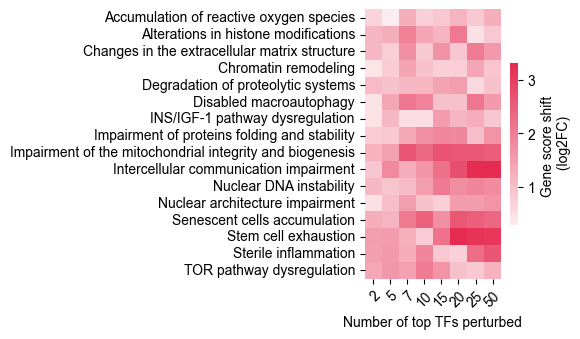

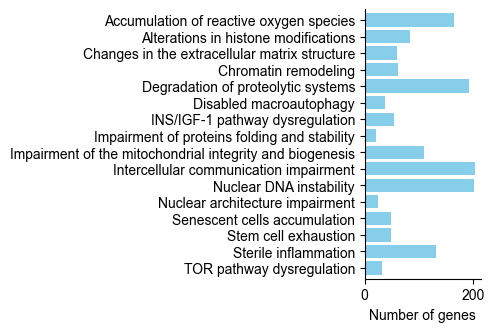

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


def barplot_pathway_counts(df_terms, ax):
    df_terms.plot(kind='barh', 
                  color='skyblue', 
                  width=0.8,
                  edgecolor=None, 
                  ax=ax, 
                  legend=False)
    ax.set_xlabel('Number of genes')
    ax.set_ylabel('')
    ax.set_title('')
    ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines

# --- Prepare data ---

df_summary_opengenes = score_shift_summary[score_shift_summary['pathway'].isin(opengenes_terms)]
df_summary_opengenes[gene_score_shift_col] = df_summary_opengenes[gene_score_shift_col].abs()
pivot_df = df_summary_opengenes.pivot_table(index='pathway', columns='n', values=gene_score_shift_col)

opengenes_terms_n = {key: len(values) for key, values in opengenes_terms.items()}
opengenes_terms_n = {k: v for k, v in opengenes_terms_n.items() if k in pivot_df.index}
df_terms = pd.DataFrame.from_dict(opengenes_terms_n, orient='index', columns=['count'])
df_terms = df_terms.loc[pivot_df.index]  # ensure order consistency
df_terms = df_terms.iloc[::-1]
# --- Plot side by side ---
fig, ax1 = plt.subplots(1, 1, figsize=(2.2, max(3.5, len(pivot_df) * 0.18)))
heatplot_perturbation_effect(pivot_df, ax1)
fig, ax2 = plt.subplots(1, 1, figsize=(1.5, max(3.5, len(pivot_df) * 0.18)))
barplot_pathway_counts(df_terms, ax2)
# ax2.set_yticklabels([])
plt.savefig(f'{plots_dir}/opengenes_gene_score_shift.png', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

Text(0.5, 9.222222222222216, '')

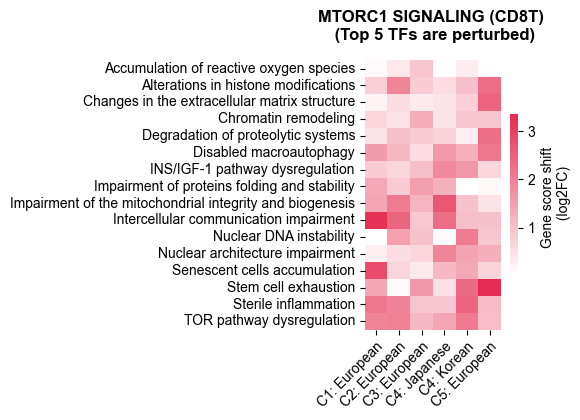

In [122]:
n = 5
df = df_summary_opengenes[df_summary_opengenes['n']==n].copy()
df['dataset'] = df['dataset'].apply(lambda x: surrogate_names[x] if x in surrogate_names else x)

pivot_df = df.pivot_table(index='pathway', columns='dataset', values=gene_score_shift_col)

fig, ax = plt.subplots(figsize=(2.2, max(3.5, len(pivot_df) * 0.18)))
heatplot_perturbation_effect(pivot_df, ax=ax)

plt.title(f'{target_pathway} ({cell_type}) \n (Top {n} TFs are perturbed)', pad=15, fontsize=12, fontweight='bold')
plt.xlabel('')

## Identify novel rejuvinating TFs

In [123]:
def simulate_perturbation(tfs):
    raw_rr = multi_tf_run_function(tfs)
    age_shift = raw_rr['age_shift']['age_shift'].mean()
    gene_score_shift_log2fc = summarize_pathway_scores(raw_rr, cols=['cell_type'])['gene_score_shift_log2fc'].abs().mean() #TODO: this is problematic. we are just assuming that any change in the gene score of these pathways are bad
    return {
        'age_shift': age_shift,         # Want to minimize
        'detr_score': gene_score_shift_log2fc          # Want to keep low
    }

In [124]:
TF_all = tf_counts[tf_counts>2].index.tolist() # this is only considering those tfs associated with a pathway and regulates at least 2 genes

### Greedy search

In [129]:
import pandas as pd
import random
import pandas as pd
from joblib import Parallel, delayed

def run_greedy_tf_optimization_parallel(
    TF_all,
    simulate_perturbation,
    max_tfs_n=5,
    constraint_threshold=2.0,
    max_iteration=100,
    n_jobs=-1  # Use all available cores
):
    selected = []
    history = []
    available_tfs = TF_all.copy()
    iteration = 0

    while len(selected) < max_tfs_n and available_tfs:
        # Parallel evaluation of all trial sets
        trial_sets = [(tf, selected + [tf]) for tf in available_tfs]

        def eval_candidate(tf, trial_set):
            res = simulate_perturbation(trial_set)
            return {
                "tf": tf,
                "age_shift": res["age_shift"],
                "detr_score": res["detr_score"],
                "valid": res["detr_score"] <= constraint_threshold
            }

        results = Parallel(n_jobs=n_jobs)(
            delayed(eval_candidate)(tf, ts) for tf, ts in trial_sets
        )

        # Find best valid candidate
        best_candidate = None
        best_age_shift = float("inf")
        best_detr_score = None

        for res in results:
            if res["valid"] and res["age_shift"] < best_age_shift:
                best_candidate = res["tf"]
                best_age_shift = res["age_shift"]
                best_detr_score = res["detr_score"]

        if best_candidate is None:
            print(f"Stopped at size {len(selected)}: no candidates met the constraint.")
            break

        selected.append(best_candidate)
        available_tfs.remove(best_candidate)

        update = {
            "step": len(selected),
            "added_tf": best_candidate,
            "tfs": ",".join(selected),
            "age_shift": best_age_shift,
            "detr_score": best_detr_score,
            "selected": True
        }
        # if True:
        #     print(update)
        history.append(update)

        iteration += 1
        if iteration > max_iteration:
            print(f"Stopped at size {len(selected)}: reached max iterations.")
            break

    df_results = pd.DataFrame(history)
    return selected, df_results

selected_tfs, df_results = run_greedy_tf_optimization_parallel(
    TF_all=TF_all,
    simulate_perturbation=simulate_perturbation,
    max_tfs_n=5,
    constraint_threshold=1.0,
    n_jobs=4
)

{'step': 1, 'added_tf': 'FOXP1', 'tfs': 'FOXP1', 'age_shift': np.float64(-31.613388211915524), 'detr_score': np.float64(0.9708085990787588), 'selected': True}
{'step': 2, 'added_tf': 'JUND', 'tfs': 'FOXP1,JUND', 'age_shift': np.float64(-31.306623647851712), 'detr_score': np.float64(0.9627326480462832), 'selected': True}
{'step': 3, 'added_tf': 'BCL11B', 'tfs': 'FOXP1,JUND,BCL11B', 'age_shift': np.float64(-36.82959992134727), 'detr_score': np.float64(0.9821211234955515), 'selected': True}


KeyboardInterrupt: 

### Bayesian optimization: best 5 TFs

In [729]:
from ax.service.managed_loop import optimize
import pandas as pd
import random

def run_tf_set_optimization(
    TF_all,
    simulate_perturbation,
    n_tfs=5,
    total_trials=50,
    constraint_threshold=2.0
):
    # --- Define Objective Function ---
    def ax_objective(params):
        tf_list = list({params[f"tf{i+1}"] for i in range(n_tfs)})
        if len(tf_list) < n_tfs:
            return {"age_shift": 10.0, "detr_score": 1.0}  # Penalize duplicates
        result = simulate_perturbation(tf_list)
        return {
            "age_shift": result["age_shift"],
            "detr_score": result["detr_score"]
        }

    # --- Search Space ---
    search_space = [
        {
            "name": f"tf{i+1}",
            "type": "choice",
            "values": TF_all,
        } for i in range(n_tfs)
    ]

    # --- Run Ax Optimization ---
    best_parameters, values, experiment, model = optimize(
        parameters=search_space,
        evaluation_function=ax_objective,
        objective_name="age_shift",
        outcome_constraints=[f"detr_score <= {constraint_threshold}"],
        total_trials=total_trials,
        minimize=True,
    )

    # --- Build Comprehensive Results DataFrame ---
    data = experiment.fetch_data().df
    df_scores = data.pivot(index="trial_index", columns="metric_name", values="mean").reset_index()

    trial_param_records = []
    for trial_index, trial in experiment.trials.items():
        arm = trial.arm
        tf_values = [v for k, v in sorted(arm.parameters.items()) if k.startswith("tf")]
        trial_param_records.append({
            "trial_index": trial_index,
            "tfs": ",".join(sorted(tf_values))
        })
    df_params = pd.DataFrame(trial_param_records)
    df_all = pd.merge(df_params, df_scores, on="trial_index")

    # Add 'selected' flag
    best_tfs_str = ",".join(sorted(best_parameters.values()))
    df_all["selected"] = df_all["tfs"] == best_tfs_str

    # Sort and return
    df_all = df_all.sort_values("age_shift").reset_index(drop=True)

    return best_parameters, values, df_all

# Run the optimization
n_tfs = 5
total_trials = 5
constraint_threshold = 2.0  # Adjust as needed
best_params, values, df_results = run_tf_set_optimization(
    TF_all=TF_all,
    simulate_perturbation=simulate_perturbation,
    n_tfs=n_tfs,
    total_trials=total_trials,
    constraint_threshold=constraint_threshold
)

[INFO 07-08 21:49:07] ax.service.utils.instantiation: Inferred value type of ParameterType.STRING for parameter tf1. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.
[INFO 07-08 21:49:07] ax.service.utils.instantiation: Inferred value type of ParameterType.STRING for parameter tf2. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.
[INFO 07-08 21:49:07] ax.service.utils.instantiation: Inferred value type of ParameterType.STRING for parameter tf3. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.
[INFO 07-08 21:49:07] ax.service.utils.instantiation: Inferred value type of ParameterType.STRING for parameter tf4. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.


Processing: CD8T - SLE_European (overexpression | multi)Processing: CD8T - data1 (overexpression | multi)

Processing: CD8T - data13_Korean (overexpression | multi)
Processing: CD8T - data7_allTPs_jalil (overexpression | multi)
Processing: CD8T - data12 (overexpression | multi)
Processing: CD8T - data13_Japanese (overexpression | multi)


[INFO 07-08 21:49:25] ax.service.managed_loop: Running optimization trial 2...
[INFO 07-08 21:49:25] ax.service.managed_loop: Running optimization trial 3...
[INFO 07-08 21:49:25] ax.service.managed_loop: Running optimization trial 4...


Processing: CD8T - data1 (overexpression | multi)
Processing: CD8T - data7_allTPs_jalil (overexpression | multi)
Processing: CD8T - SLE_European (overexpression | multi)
Processing: CD8T - data12 (overexpression | multi)
Processing: CD8T - data13_Korean (overexpression | multi)
Processing: CD8T - data13_Japanese (overexpression | multi)


[INFO 07-08 21:49:37] ax.service.managed_loop: Running optimization trial 5...


Processing: CD8T - data1 (overexpression | multi)
Processing: CD8T - data7_allTPs_jalil (overexpression | multi)
Processing: CD8T - data12 (overexpression | multi)
Processing: CD8T - SLE_European (overexpression | multi)
Processing: CD8T - data13_Korean (overexpression | multi)
Processing: CD8T - data13_Japanese (overexpression | multi)


In [ ]:
def get_run_record(experiment, best_parameters):
    # 1. Fetch scores from Ax experiment
    data = experiment.fetch_data().df

    # 2. Extract TFs and combine into a single column
    trial_param_records = []

    for trial_index, trial in experiment.trials.items():
        arm = trial.arm
        tf_values = [v for k, v in sorted(arm.parameters.items()) if k.startswith("tf")]
        trial_param_records.append({
            "trial_index": trial_index,
            "tfs": ",".join(sorted(tf_values))  # sort to standardize order
        })

    df_params = pd.DataFrame(trial_param_records)

    # 3. Reshape scores to wide format
    df_scores = data.pivot(index="trial_index", columns="metric_name", values="mean").reset_index()

    # 4. Merge
    df_all = pd.merge(df_params, df_scores, on="trial_index")
    chosen_tfs = sorted(best_parameters.values())
    chosen_tfs_str = ",".join(chosen_tfs)

    # Add 'selected' column: True if tfs match the chosen set
    df_all["selected"] = df_all["tfs"] == chosen_tfs_str
    return df_all
run_record = get_run_record(experiment, best_parameters)
run_record

,trial_index,tfs,age_shift,detr_score,selected
0,0,"BHLHE40,KLF6,MAF,PLAG1,ZBTB38",68.048266,1.441716,False
1,1,"ASCL2,LEF1,PRDM1,TBX21,ZNF331",-1.423522,1.117078,False
2,2,"CEBPD,DRAP1,DRAP1,IRF1,JAZF1",10.000000,1.000000,False
3,3,"ASCL2,BACH2,CEBPD,FOXP1,JAZF1",-58.125669,0.996927,True
4,4,"BCL11B,MYC,NFATC2,NR4A2,ZNF683",-10.101948,1.212646,False


In [ ]:
aaa 

NameError: name 'aaa' is not defined

# Single aging TF perturbation

In [ ]:
datasets = datasets_all[:2]
if True:
    from ciim.src.insilico_perturbation.helper import wrapper_in_silico_single_perturbation
    # --- Single TF Perturbation ---
    # save_file = f"{save_dir}/perturbation/single_aging_tf_perturbation.csv"
    stats_aging = retrieve_sig_stats(type='bulk', race='both', filter_inconsistent=True)

    perturb_rr_dict = {}
    for cell_type in cell_types:
        tfs = stats_aging[stats_aging['cell_type'] == cell_type]['tf'].unique()
        
        par_single = {
            'simulation_iteration': simulation_iteration,
            'n_donors': n_donors,
            'data_type': data_type,
            'version': version,
            'reg_type': reg_type,
            'feature_type': 'gene_expression',
            'perturbation_mode': 'overexpression',
        }
        perturb_rr = wrapper_in_silico_single_perturbation(tfs=tfs, par=par_single, n_jobs=n_jobs, cell_types=[cell_type], datasets=datasets)
        perturb_rr_dict[cell_type] = perturb_rr
    # perturb_rr.to_csv(save_file)
else:
    save_file=f"{save_dir}/perturbation/single_aging_tf_perturbation.csv"
    perturb_rr = pd.read_csv(save_file, index_col=0)
    print(f"Loaded {len(perturb_rr)} results from {save_file}")


Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpression)
Processing: CD4T - data1 (overexpr

## Check the normality of age shift

In [49]:
perturb_rr_mean_store = []
for cell_type, perturb_rr in perturb_rr_dict.items():
    perturb_rr_mean = perturb_rr.groupby(['cell_type','dataset', 'tf'])['age_shift'].apply(lambda x: x['age_shift'].mean()).reset_index(name='mean_diff')
    perturb_rr_mean_store.append(perturb_rr_mean)
perturb_rr_mean = pd.concat(perturb_rr_mean_store)
perturb_rr_mean.head()

,cell_type,dataset,tf,mean_diff
0,CD4T,data1,AHR,0.054157
1,CD4T,data1,ARHGAP35,-1.831377
2,CD4T,data1,ARID5B,-1.042753
3,CD4T,data1,BACH2,-32.296655
4,CD4T,data1,BATF,-3.332738


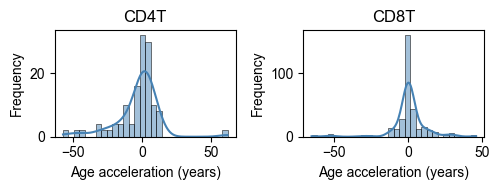

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Unique cell types
cell_types = perturb_rr_mean['cell_type'].unique()
n = len(cell_types)

# Determine subplot grid size
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2))
axes = axes.flatten()  # Flatten in case of 2D axes array

for i, cell_type in enumerate(cell_types):
    df = perturb_rr_mean[perturb_rr_mean['cell_type'] == cell_type].copy()
    
    ax = axes[i]

    sns.histplot(df['mean_diff'], bins=30, kde=True, color='steelblue', ax=ax)
    ax.set_title(cell_type)
    ax.set_xlabel('Age acceleration (years)')
    ax.set_ylabel('Frequency')

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Significance of age acceleration per TF

In [51]:
# - normalized significance
from scipy.stats import norm

perturb_rr_mean['z_score'] = perturb_rr_mean.groupby('cell_type')['mean_diff'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# perturb_rr_mean['empirical_pval_two_sided'] = 2 * norm.sf(np.abs(perturb_rr_mean['z_score']))
# perturb_rr_mean['signed_neg_log10_pval'] = -np.sign(perturb_rr_mean['mean_diff']) * np.log10(perturb_rr_mean['empirical_pval_two_sided'])
# perturb_rr_mean.head()

In [52]:
stats_aging = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['tf', 'cell_type'])[['tf', 'cell_type', 'trend']]
perturb_rr_mean = perturb_rr_mean.merge(stats_aging, on=['tf', 'cell_type'], how='left')
perturb_rr_mean.head()

,cell_type,dataset,tf,mean_diff,z_score,trend
0,CD4T,data1,AHR,0.054157,0.192748,Increase in aging
1,CD4T,data1,ARHGAP35,-1.831377,0.076405,Increase in aging
2,CD4T,data1,ARID5B,-1.042753,0.125066,Increase in aging
3,CD4T,data1,BACH2,-32.296655,-1.803392,Decrease in aging
4,CD4T,data1,BATF,-3.332738,-0.016233,Increase in aging


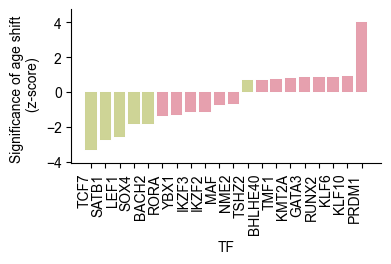

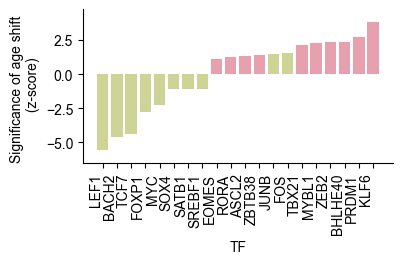

In [ ]:
from ciim.src.insilico_perturbation.plots import wrapper_plot_age_acceleration_for_tf_perturbation

value_col= 'z_score' #'mean_diff' #'z_score'#'signed_neg_log10_pval'
features = None
top_n=20

top_tfs_dict = {}
for cell_type in cell_types:
    perturb_rr_mean_t = perturb_rr_mean[perturb_rr_mean['cell_type'] == cell_type]

    if False:
        # filter for sig aging TFs
        aging_stats = retrieve_sig_stats(type='bulk')
        aging_tfs = aging_stats[aging_stats['cell_type'] == cell_type]['tf'].unique()
        perturb_rr_mean_t = perturb_rr_mean_t[perturb_rr_mean_t['tf'].isin(aging_tfs)]
    
    aa, top_tfs = wrapper_plot_age_acceleration_for_tf_perturbation(perturb_rr_mean_t, 
                                            value_col=value_col, 
                                            top_n=top_n,
                                            figsize=(4, 2))
    # plt.legend().remove()
    top_tfs_dict[cell_type] = top_tfs
    plt.title(f"", pad=15, weight='bold')
    plt.savefig(f"{plots_dir}/aging_tf_perturbation_{cell_type}.png", bbox_inches='tight', dpi=300, transparent=True)

## Aging trends: verification

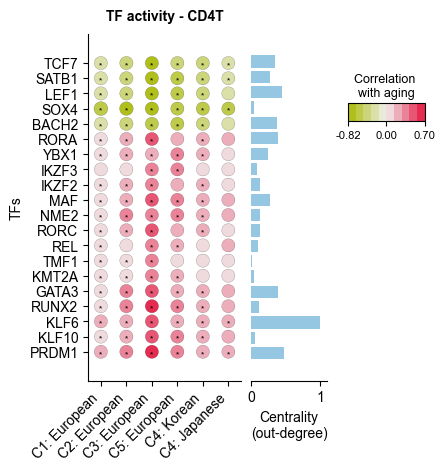

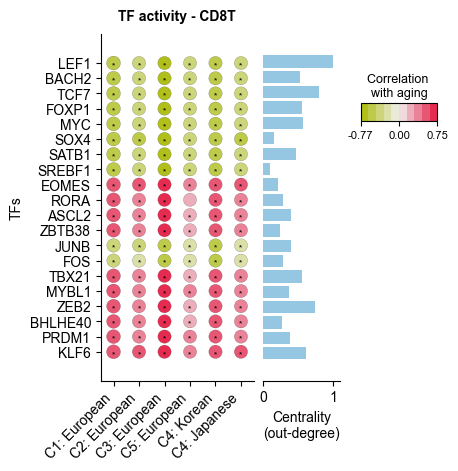

In [374]:
for cell_type in cell_types:
    top_tfs = top_tfs_dict[cell_type]
    df_cell = perturb_rr_mean[perturb_rr_mean['cell_type'] == cell_type].copy()
    

    # median_abs = df_cell.groupby('tf')[value_col].apply(lambda x: x.abs().median())

    # Keep only top TFs
    df_cell = df_cell[df_cell['tf'].isin(top_tfs)].copy()

    # Sort TFs by signed mean_diff for plotting
    tf_order = df_cell.groupby('tf')[value_col].mean().sort_values().index
    df_cell['tf'] = pd.Categorical(df_cell['tf'], categories=tf_order, ordered=True)
    df_cell['tf'].cat.categories

    features = df_cell['tf'].cat.categories
    from ciim.src.tf_activity.plots import plot_features_vs_datasets
    bb = plot_features_vs_datasets(cell_type=cell_type, type='bulk', datasets=datasets_all, features=features, feature_type='tf_activity', 
                                sizes=(90, 100), width=4,
                                margins_ax1={'x': 0.1, 'y': 0.1}, margins_ax2={'x': 0.1, 'y': 0.07})
    # plt.suptitle(f"", fontsize=12, weight='bold')
    plt.savefig(f"{plots_dir}/{cell_type}_tf_activity.png", bbox_inches='tight', dpi=300, transparent=True)

## Consistency of the age shift with aging TFs: verification 

In [ ]:
# Import dependencies
from ciim.src.tf_activity.helper import retrieve_sig_stats

# Get the sign of slope for perturbation analysis
# perturb_rr_sig = perturb_rr[perturb_rr['signed_neg_log10_pval'].abs()>1.4]
perturb_slope_sign = (
    perturb_rr_mean.groupby(['cell_type', 'tf'])['mean_diff']
    .median()
    .apply(np.sign)
    .reset_index()
    .rename(columns={'mean_diff': 'slope'})
)


# Get the sign of slope for aging TFs (reference)
stats = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['tf', 'cell_type'])
aging_slope_sign = (
    stats.groupby(['cell_type', 'tf'])['slope']
    .median()
    .apply(np.sign)
    .reset_index()
    .rename(columns={'slope': 'slope'})
)

# Cell type-specific overlap
overlap_results = []

for cell_type in cell_types:
    # Subset aging (reference) and perturbation data
    aging_t = aging_slope_sign[aging_slope_sign['cell_type'] == cell_type]
    perturb_t = perturb_slope_sign[perturb_slope_sign['cell_type'] == cell_type]
    # Merge on TFs that are found in both
    merged = aging_t.merge(perturb_t, on='tf', suffixes=('_aging', '_perturb'), how='inner')

    if merged.empty:
        continue

    # Count matches with respect to aging slope
    matched = (merged['slope_aging'] == merged['slope_perturb']).sum()
    total = merged.shape[0]
    fraction_matched = matched / total

    overlap_results.append({
        'cell_type': cell_type,
        'n_ref_tfs': len(aging_t),
        'n_overlap_tfs': total,
        'n_matched': matched,
        'percent_matched': 100*fraction_matched
    })


overlap_df = pd.DataFrame(overlap_results)
overlap_df

,cell_type,n_ref_tfs,n_overlap_tfs,n_matched,percent_matched
0,CD4T,67,67,39,58.208955
1,CD8T,163,163,133,81.595092


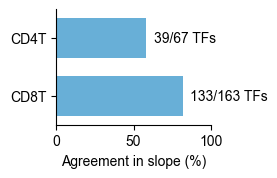

In [413]:
import matplotlib.pyplot as plt
import seaborn as sns
figsize=(2, 1.5)
def plot_tf_slope_overlap(overlap_df):
    fig, ax = plt.subplots(figsize=figsize)

    # Plot the bars
    barplot = sns.barplot(
        data=overlap_df,
        x='percent_matched',
        y='cell_type',
        ax=ax,
        width=0.7,
        # palette='viridis'
        color=colors_blind[1],
    )

    # Add text labels directly on the bars
    for bar, (_, row) in zip(barplot.patches, overlap_df.iterrows()):
        width = bar.get_width()
        y_center = bar.get_y() + bar.get_height() / 2
        label = f"{int(row['n_matched'])}/{int(row['n_overlap_tfs'])} TFs"
        ax.text(width + 5, y_center, label, va='center', ha='left', fontsize=10, color='black')

    ax.set_xlim(0, 100)
    ax.set_xlabel('Agreement in slope (%)')
    ax.set_ylabel('')
    sns.despine()
    return fig

# Usage
aa = plot_tf_slope_overlap(overlap_df[overlap_df['cell_type'].isin(['CD4T', 'CD8T', 'MONO', 'NK'])])
plt.savefig(f"{plots_dir}/aging_tf_slope_overlap.png", bbox_inches='tight', dpi=300, transparent=True)

## Pathway scores

In [74]:
cell_type = 'CD8T'
ordered_top_tfs = top_tfs_dict[cell_type]
perturb_rr = perturb_rr_dict[cell_type].copy()
perturb_rr = perturb_rr[perturb_rr['tf'].isin(ordered_top_tfs)].copy()
score_shift_summary = summarize_pathway_scores(perturb_rr, cols=['cell_type', 'dataset', 'tf'])
df_summary_opengenes = score_shift_summary[score_shift_summary['pathway'].isin(opengenes_terms)]
df_summary_opengenes[gene_score_shift_col] = df_summary_opengenes[gene_score_shift_col].abs()
pivot_df = df_summary_opengenes.pivot_table(index='pathway', columns='tf', values=gene_score_shift_col)
pivot_df = pivot_df[ordered_top_tfs]  # reorder columns based on ordered_top_tfs

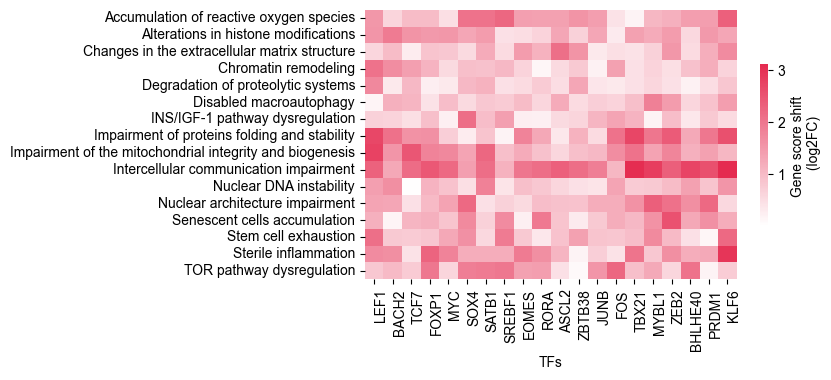

In [97]:
fig, ax1 = plt.subplots(1, 1, figsize=(6, max(3.5, len(pivot_df) * 0.18)))
heatplot_perturbation_effect(pivot_df, ax1)
ax1.set_xlabel('TFs')
bb = ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha='right', rotation_mode='anchor')

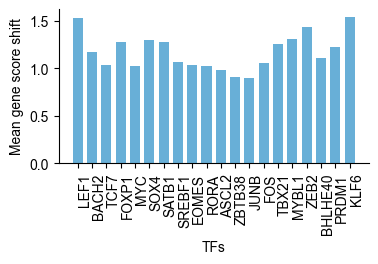

In [ ]:
mean_pivot_df = pivot_df.mean(axis=0).reset_index(name='mean_value')
fig, ax = plt.subplots(figsize=(4, 2))
barplot = sns.barplot(
        data=mean_pivot_df,
        y='mean_value',
        x='tf',
        ax=ax,
        width=0.7,
        # palette='viridis'
        color=colors_blind[1],
    )
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
ax.set_ylabel('Mean gene score shift')
ax.set_xlabel('TFs')
ax.margins(x=0.05, y=0.05)
bb = ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', rotation_mode='anchor')

# Combinatorial aging TFs perturbation

In [357]:
datasets = datasets_all

In [377]:
def run_all_aging_tf_perturbation():
    print('Running all aging TF perturbation...')
    par_aging = {
        'simulation_iteration': simulation_iteration,
        'n_donors': n_donors,
        'data_type': data_type,
        'version': version,
        'reg_type': reg_type,
        'feature_type': 'gene_expression',
        'perturbation_mode': 'natural_aging',
        'tfs': 'aging',
    }
    df_all = wrapper_in_silico_perturbation(par_aging, n_jobs=n_jobs, cell_types=cell_types, datasets=datasets)
    return df_all
df_natural_aging = run_all_aging_tf_perturbation()

Running all aging TF perturbation...
Processing: CD4T - data1 (natural_aging | multi)
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for APICAL SURFACE: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for HEDGEHOG SIGNALING: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for MYC TARGETS V2: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for NOTCH SIGNALING: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for PANCREAS BETA CELLS: Error calculating gene scores: Privided genes 

Text(0.5, 1.25, 'Combinatorial perturbation of aging TFs: CD4T')

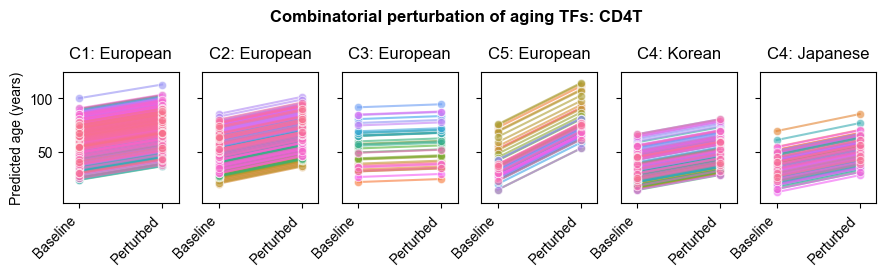

In [ ]:
from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
cell_type = cell_types[0]
datasets = df_natural_aging['dataset'].unique()
n_datasets = len(datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
for i, dataset in enumerate(datasets):
    ax = axes[i] if n_datasets > 1 else axes
    df = df_natural_aging[(df_natural_aging['cell_type'] == cell_type) & (df_natural_aging['dataset'] == dataset)].copy()
    df = df['age_shift'].copy()

    # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
    # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
    plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
    ax.set_title(f"{surrogate_names[dataset]}", pad=10)

plt.suptitle(f"Combinatorial perturbation of aging TFs: {cell_type}", y=1.25, fontsize=12, fontweight='bold')

['CD4T' 'CD8T']


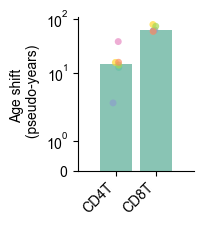

In [427]:
df_mean_aging = df_natural_aging.groupby(['cell_type', 'dataset'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
df_mean_aging['dataset'] = pd.Categorical(df_mean_aging['dataset'], categories=datasets_all, ordered=True)
fig = plot_age_acceleration(df_mean_aging[df_mean_aging['cell_type'].isin(['CD4T', 'CD8T', 'NK' ,'MONO'])], 
                            log_y=True, figsize=(1.5, 2),
                            margins=(0.3, 0.4))
plt.legend().remove()
# plt.title('Combinatorial perturbation of aging TFs\n (natural aging mode)', pad=15)

# Combinatorial perturbation of SLE associated aging TFs

In [362]:
# --- SLE TF Perturbation ---
def retrieve_sig_stats_disease(dataset='', feature_type='tf_activity', test_type='unpaired', type='bulk'):
    stats_drug = pd.read_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv', index_col=0)
    return stats_drug[(stats_drug['p_value_adj'] < 0.05) & (stats_drug['age_group'] == 'Both age groups')].copy()

def get_overlapping_tf_slopes_in_disease_and_aging(stats_disease_sig):
    stats_aging_sig = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['cell_type', 'tf'])[['cell_type', 'tf']]
    stats_disease_sig = stats_disease_sig[['cell_type', 'tf', 'slope_condition']].drop_duplicates()
    stats_both = stats_aging_sig.merge(stats_disease_sig, on=['cell_type', 'tf'], how='inner')
    return stats_both.set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type']]


In [ ]:
def run_sle_tf_perturbation():
    print('Running SLE TF perturbation...')
    dataset = 'SLE_European'
    stats_disease_sig = retrieve_sig_stats_disease(dataset=dataset)
    if True: # overlap with aging TFs
        slope_sle = get_overlapping_tf_slopes_in_disease_and_aging(stats_disease_sig)
    else: # SLE TFs
        slope_sle = stats_disease_sig[['tf','cell_type','slope_condition']].set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type']]
        print(slope_sle.groupby('cell_type').size())
    slope_sle['slope'] = np.sign(slope_sle['slope']) 
    par_sle = {
        'simulation_iteration': simulation_iteration,
        'n_donors': n_donors,
        'data_type': data_type,
        'version': version,
        'reg_type': reg_type,
        'feature_type': 'gene_expression',
        'perturbation_mode': None,
        'slope_df': slope_sle,
    }
    df_sle = wrapper_in_silico_perturbation(par_sle, n_jobs=1, cell_types=cell_types, datasets=datasets_all)
    return df_sle
df_sle = run_sle_tf_perturbation()

Running SLE TF perturbation...
Processing: CD4T - data1 (None | multi)
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for APICAL SURFACE: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for HEDGEHOG SIGNALING: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for MYC TARGETS V2: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for NOTCH SIGNALING: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for PANCREAS BETA CELLS: Error calculating gene scores: Privided genes list is empty..

Text(0.5, 1.25, 'Combinatorial perturbation of SLE-affected aging TFs: CD4T')

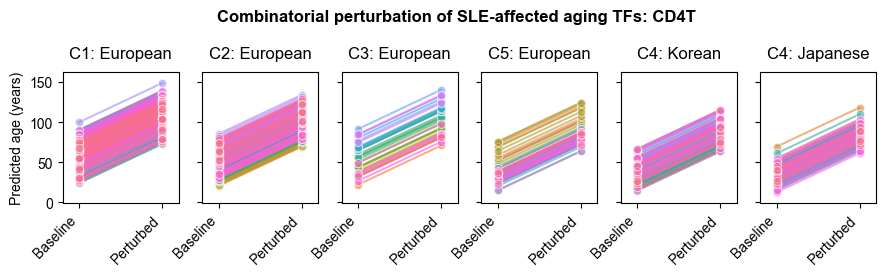

In [ ]:
from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
cell_type = cell_types[0]
datasets = df_sle['dataset'].unique()
n_datasets = len(datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
for i, dataset in enumerate(datasets):
    ax = axes[i] if n_datasets > 1 else axes
    df = df_sle[(df_sle['cell_type'] == cell_type) & (df_sle['dataset'] == dataset)].copy()
    df = df['age_shift'].reset_index()
    # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
    # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
    plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
    ax.set_title(f"{surrogate_names[dataset]}", pad=10)

plt.suptitle(f"Combinatorial perturbation of SLE-affected aging TFs: {cell_type}", y=1.25, fontsize=12, fontweight='bold')

['CD4T' 'CD8T']


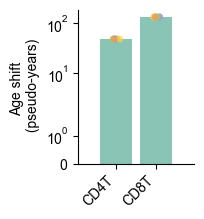

In [ ]:
df_mean_sle = df_sle.groupby(['cell_type', 'dataset'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
df_mean_sle['dataset'] = pd.Categorical(df_mean_sle['dataset'], categories=datasets_all, ordered=True)
fig = plot_age_acceleration(df_mean_sle[df_mean_sle['cell_type'].isin(['CD4T', 'CD8T', 'NK' ,'MONO'])], log_y=True,
                               figsize=(1.5, 2),
                            margins=(0.3, 0.4), color=colors_blind[2])
plt.legend().remove()
plt.savefig(f'{plots_dir}/sle_tf_perturbation.png', bbox_inches='tight', dpi=300, transparent=True)
# plt.title(f'Perturbation of aging TFs \n associated with SLE disease', pad=15)

# Drug perturbation

In [367]:
# --- Drug Perturbation ---
def retrieve_sig_stats_drug(feature_type='tf_activity', dataset='CXCL9', test_type='paired', type='bulk'):
    stats_drug = pd.read_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv', index_col=0)
    return stats_drug[(stats_drug['p_value_adj'] < 0.05)].copy()

def get_overlapping_tf_slopes_in_drug_and_aging(stats_drug_sig):
    stats_aging_sig = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['cell_type', 'tf'])[['cell_type', 'tf']]
    stats_drug_sig = stats_drug_sig[['cell_type', 'tf', 'slope_condition', 'comparision']].drop_duplicates()
    stats_both = stats_aging_sig.merge(stats_drug_sig, on=['cell_type', 'tf'], how='inner')
    return stats_both.set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type', 'comparision']]

In [383]:
from ciim.src.insilico_perturbation.helper import wrapper_in_silico_perturbation
def run_perturbation_tf_perturbation():
    print('Running drug perturbation TF perturbation...')
    stats_drug_sig = retrieve_sig_stats_drug(dataset='CXCL9')
    if True: # overlapping TFs
        df_slope = get_overlapping_tf_slopes_in_drug_and_aging(stats_drug_sig)
    else:
        df_slope = stats_drug_sig.set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type', 'comparision']]
    print(df_slope.groupby(['cell_type', 'comparision']).size())
    df_slope['slope'] = np.sign(df_slope['slope'])
    df_slope.head()
    df_store = []
    # for comparision in tqdm(df_slope['comparision'].unique()):
    for comparision in ['LPS (ctr: RPMI)', 'Ruxolitinib (ctr: LPS)']: #['Ruxolitinib (ctr: LPS)']
        df_slope_c = df_slope[df_slope['comparision'] == comparision].copy()

        par = {
            'simulation_iteration': simulation_iteration,
            'n_donors': n_donors,
            'data_type': data_type,
            'version': version,
            'reg_type': reg_type,
            'feature_type': 'gene_expression',
            'perturbation_mode': None,
            'slope_df': df_slope_c,
        }
        df_all_c = wrapper_in_silico_perturbation(par, 
                                    n_jobs=n_jobs,
                                    cell_types=cell_types,
                                    datasets=datasets_all #['data1', 'data12']# aging_clock_train_datasets, #['data12'] # datasets_all
                                    )
        df_all_c['comparision'] = comparision
        df_store.append(df_all_c)
    df_all = pd.concat(df_store)
    # df_all.to_csv(f"{save_dir}/perturbation/tf_screen_results_drug_perturbation.csv")
    return df_all
df_perturbation_all = run_perturbation_tf_perturbation()

Running drug perturbation TF perturbation...
cell_type  comparision            
CD4T       LPS (ctr: RPMI)            53
CD8T       LPS (ctr: RPMI)            49
           Ruxolitinib (ctr: LPS)     98
MONO       LPS (ctr: RPMI)            35
           Metformin (ctr: LPS)       35
           Ruxolitinib (ctr: LPS)     20
           Ruxolitinib (ctr: RPMI)    31
NK         LPS (ctr: RPMI)            20
dtype: int64
Processing: CD4T - data1 (None | multi)
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for APICAL SURFACE: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for HEDGEHOG SIGNALING: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for MYC TARGETS V2: E

In [384]:
from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
if False: # donor level plots
    from ciim.src.insilico_perturbation.helper import perform_stat_test
    cell_type = cell_types[0]
    for comparision in df_perturbation_all['comparision'].unique():
        print(comparision)
        datasets = df_perturbation_all['dataset'].unique()
        n_datasets = len(datasets)
        fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
        for i, dataset in enumerate(datasets):
            ax = axes[i] if n_datasets > 1 else axes
            df = df_perturbation_all[(df_perturbation_all['cell_type'] == cell_type) & (df_perturbation_all['dataset'] == dataset)  & (df_perturbation_all['comparision'] == comparision)].copy()
            df = df['age_shift'].reset_index()
            # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
            # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
            plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
            ax.set_title(f"{surrogate_names[dataset]}", pad=10)

        plt.suptitle(f"Treatment: {comparision}", y=1.25, fontsize=12, fontweight='bold')
    # comparision = 'Ruxolitinib (ctr: LPS)'
    # datasets = df_all['dataset'].unique()
    # n_datasets = len(datasets)
    # fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
    # for i, dataset in enumerate(datasets):
    #     ax = axes[i] if n_datasets > 1 else axes
    #     df = df_all[(df_all['cell_type'] == cell_type) & (df_all['dataset'] == dataset)  & (df_all['comparision'] == comparision)].copy()

    #     # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
    #     # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
    #     plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
    #     ax.set_title(f"{surrogate_names[dataset]}", pad=10)

    # plt.suptitle(f"Treatment: {comparision}", y=1.25, fontsize=12, fontweight='bold')

['CD4T']
['CD8T']


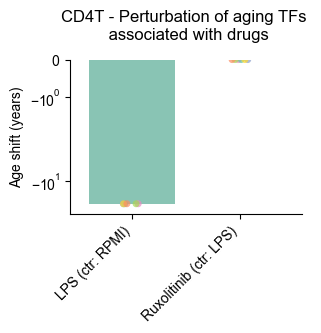

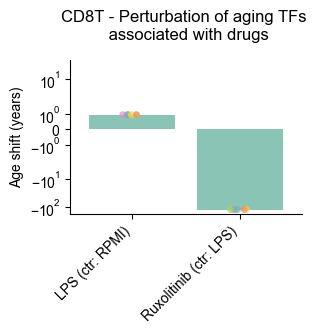

In [ ]:
for cell_type in df_perturbation_all['cell_type'].unique():
    df = df_perturbation_all[df_perturbation_all['cell_type'] == cell_type].copy()
    # df_mean = df.groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median().reset_index(name='mean_diff')
    df_mean = df.groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
    df_mean['dataset'] = pd.Categorical(df_mean['dataset'], categories=datasets_all, ordered=True)
    plot_age_acceleration(df_mean, x_col='comparision', log_y=True, figsize=(3, 2),
                            margins=(0.1, 0.4))
    plt.legend().remove()
    plt.title(f"{cell_type} - Perturbation of aging TFs \n associated with drugs", pad=15)

# Summary plot of all combinatorial perturbations

In [434]:
df_mean_ruxo = df_perturbation_all[(df_perturbation_all['comparision'] == 'Ruxolitinib (ctr: LPS)')].groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
    

['CD4T']
['CD8T']


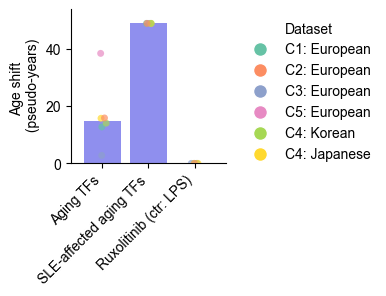

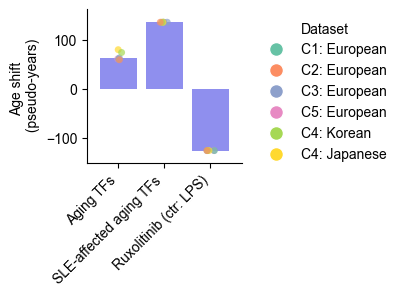

In [435]:
for cell_type in cell_types:
    df_mean_ruxo_c = df_mean_ruxo[(df_mean_ruxo['cell_type'] == cell_type)]
    df_mean_sle_c = df_mean_sle[(df_mean_sle['cell_type'] == cell_type)].copy()
    df_mean_aging_c = df_mean_aging[(df_mean_aging['cell_type'] == cell_type)].copy()

    df_mean_ruxo_c['experiment'] = 'Ruxolitinib (ctr: LPS)'
    df_mean_sle_c['experiment'] = 'SLE-affected aging TFs'
    df_mean_aging_c['experiment'] = 'Aging TFs'

    df_mean = pd.concat([df_mean_aging_c, df_mean_sle_c, df_mean_ruxo_c], ignore_index=True)

    # Normalize by aging TFs
    # df_aging_vals = df_mean[df_mean['experiment'] == 'Aging TFs'][['dataset', 'age_shift']].rename(
    #     columns={'age_shift': 'age_shift_aging'}
    # )

    # df_mean = df_mean.merge(df_aging_vals, on='dataset', how='left')
    # df_mean['age_shift'] = df_mean['age_shift'] / df_mean['age_shift_aging']

    df_mean['dataset'] = pd.Categorical(df_mean['dataset'], categories=datasets_all, ordered=True)

    plot_age_acceleration(df_mean, x_col='experiment', log_y=False, figsize=(2, 2),
                                margins=(0.1, .1))
    plt.savefig(f"{plots_dir}/aging_tf_perturbation_summary_{cell_type}.png", bbox_inches='tight', dpi=300, transparent=True)

In [ ]:
df_perturbation_all['comparision'].unique()

array(['LPS (ctr: RPMI)', 'Ruxolitinib (ctr: LPS)'], dtype=object)

['CD4T' 'CD8T']
['CD4T' 'CD8T']
['CD4T' 'CD8T']
['CD4T' 'CD8T']


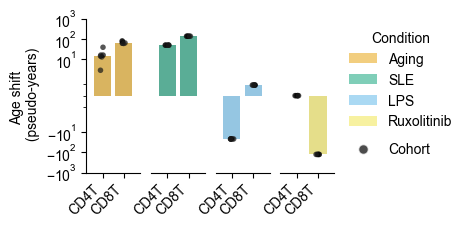

In [562]:
alpha=0.7
color_dataset='black'

df_mean_aging = df_natural_aging.groupby(['cell_type', 'dataset'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
df_mean_sle = df_sle.groupby(['cell_type', 'dataset'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
df_mean_ruxo = df_perturbation_all[(df_perturbation_all['comparision'] == 'Ruxolitinib (ctr: LPS)')].groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
df_mean_lps = df_perturbation_all[(df_perturbation_all['comparision'] == 'LPS (ctr: RPMI)')].groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median()['age_shift']['age_shift'].reset_index()


experiments = ['Aging', 'SLE', 'LPS', 'Ruxolitinib']
dfs = [df_mean_aging, df_mean_sle, df_mean_lps, df_mean_ruxo]
colors = [colors_blind[0], colors_blind[2], colors_blind[1], colors_blind[3]]

# df_combined = pd.concat(dfs, ignore_index=True)
# min_age_shift = df_combined['age_shift'].min()
# max_age_shift = df_combined['age_shift'].max()
# lim = [min_age_shift-20, max_age_shift+20]

fig, axes = plt.subplots(1, len(experiments), figsize=(.8 * len(experiments), 2), sharey=False)


def plot_age_shift(df_all, 
                        x_col='cell_type', 
                        figsize=(3, 3),
                        color='blue',
                        ax=None):
    # If a specific order is given, enforce it
    order = df_all[x_col].unique()
    print(df_all['cell_type'].unique())
    # Calculate median per category
    df_median = df_all.groupby(x_col)['age_shift'].median().reset_index()
    # Plotting
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    df_all['dataset'] = df_all['dataset'].apply(lambda name: surrogate_names.get(name, name))
    sns.stripplot(ax=ax, data=df_all, y='age_shift', x=x_col, hue='dataset',
                  color=color_dataset, alpha=alpha, order=order, s=4)

    sns.barplot(ax=ax, data=df_median, y='age_shift', x=x_col, alpha=alpha, color=color, order=order)
    
    # Axes and labels
    ax.set_ylabel("Age shift \n (pseudo-years)")
    ax.set_xlabel("")
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    
for experiment, df in zip(experiments, dfs):
    
    i = experiments.index(experiment)
    ax = axes[i]
    color = colors[i]
    df['dataset'] = pd.Categorical(df['dataset'], categories=datasets_all, ordered=True)

    plot_age_shift(df, color=color, ax=ax)
    # ax.get_legend().remove()
    # ax.set_ylim(lim)
    
    ax.get_legend().remove()

    # - log x axis
    ax.set_yscale('symlog')
    ax.set_yticks([-1000, -100, -10, 10, 100, 1000])
    # ax.set_yticklabels(['-100', '-10', '10', '100'])
    ax.margins(x=0.2)
    if i != 0:
        ax.set_ylabel('')
        ax.set_yticks([])  # Ensure no ticks are shown
        ax.set_yticklabels([])  # Also clear any existing labels
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)
        ax.spines['left'].set_visible(False)
         
def plot_legends(ax):
    import matplotlib.patches as mpatches
    from matplotlib.lines import Line2D
    legend1_handles = [
        Line2D([0], [0], marker='o', color='w',
            markerfacecolor=color_dataset, alpha=alpha,
            markersize=7, label='Cohort', linestyle='None')
    ]
    legend1 = ax.legend(handles=legend1_handles, title='',
                        bbox_to_anchor=(1.05, 0.15), loc='center left', frameon=False)
    ax.add_artist(legend1)
    legend2_handles = [
        Patch(facecolor=colors[i], edgecolor=None, label=ds, alpha=0.5)
        for i, ds in enumerate(experiments)
    ]
    ax.legend(handles=legend2_handles, title='Condition',
            bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plot_legends(ax)
plt.savefig(f'{plots_dir}/multi_tf_perturbation.png', bbox_inches='tight', dpi=300, transparent=True)
# plt.title(f'Perturbation of aging TFs \n associated with SLE disease', pad=15)